In [1]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

Loading required package: pacman



In [2]:
data <- read_csv("../data/output/combined_hcris_mcaid_new.csv")

data <- data %>%
  mutate(
    expanded = !is.na(expansion_date),
    date_adopted = as.Date(expansion_date)
  )

Rows: 161060 Columns: 46
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (10): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (5): fy_start, fy_end, date_processed, date_created, expansion_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Problem 1

In [28]:
data_1 <- data %>%
  mutate(
    Year = year,
    uncomp_care_m = uncomp_care / 1e6
  )

data_1 %>%
  filter(Year >= 2010, Year <= 2018) %>%
  group_by(Year) %>%
  summarize(
    Mean = mean(uncomp_care_m, na.rm = TRUE),
    N = sum(!is.na(uncomp_care_m)),
    .groups = "drop"
  ) %>%
  kbl(
    digits = 5,
    format = "html",
    col.names = c("Year", "Mean Uncompensated Care ($M)", "No. of Hospitals"),
    caption = "Table 1: Mean Uncompensated Care by Year (2010–2018)"
  ) %>%
  kable_styling(
    bootstrap_options = "basic",
    full_width = FALSE
  )

<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Table 1: Mean Uncompensated Care by Year (2010–2018)</caption>
 <thead>
  <tr>
   <th style="text-align:right;"> Year </th>
   <th style="text-align:right;"> Mean Uncompensated Care ($M) </th>
   <th style="text-align:right;"> No. of Hospitals </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;"> 2010 </td>
   <td style="text-align:right;"> 30.02459 </td>
   <td style="text-align:right;"> 2816 </td>
  </tr>
  <tr>
   <td style="text-align:right;"> 2011 </td>
   <td style="text-align:right;"> 33.83339 </td>
   <td style="text-align:right;"> 2480 </td>
  </tr>
  <tr>
   <td style="text-align:right;"> 2012 </td>
   <td style="text-align:right;"> 37.26657 </td>
   <td style="text-align:right;"> 2617 </td>
  </tr>
  <tr>
   <td style="text-align:right;"> 2013 </td>
   <td style="text-align:right;"> 39.31041 </td>
   <td style="text-align:right;"> 2707 </td>
  </tr>
  <tr>

## Problem 2 

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year and expand_group.
ℹ Output is grouped by year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, expand_group))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
Warning message:
“Removed 2 rows containing missing values (`geom_line()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_point()`).”


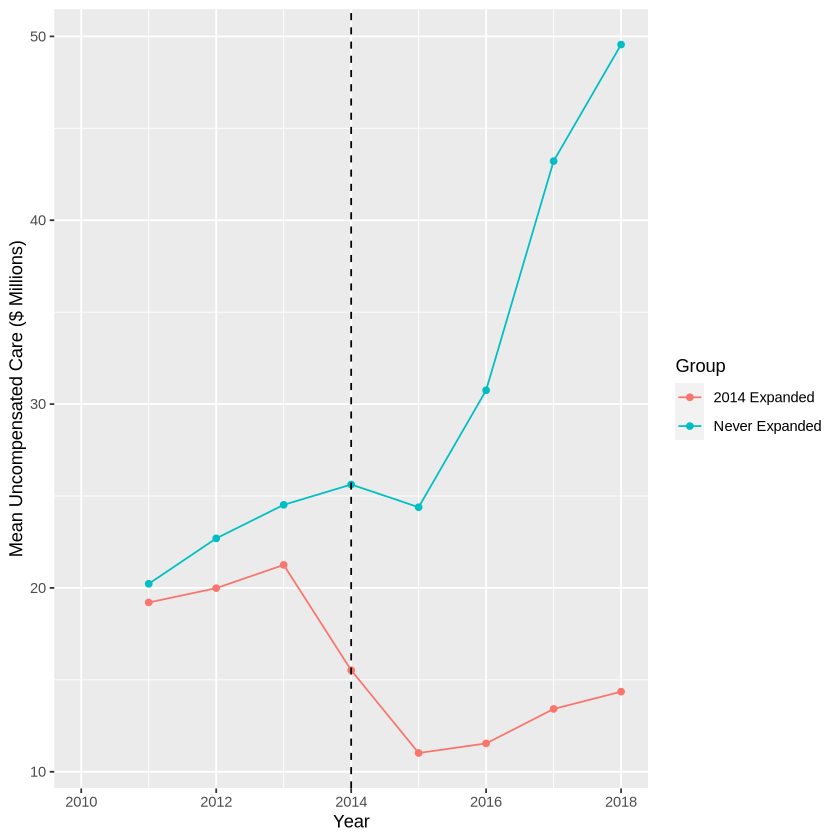

In [18]:
data_filtered <- data %>%
filter(year >= 2010, year <= 2018) %>%
  mutate(expand_group = case_when(
    expanded == FALSE ~ "Never Expanded",
    as.Date(date_adopted) == as.Date("2014-01-01") ~ "2014 Expanded"
  )) %>%
  filter(!is.na(expand_group))

data_filtered %>%
  group_by(year, expand_group) %>%
  summarise(mean_uncomp = mean(tot_uncomp_care_charges, na.rm = TRUE) / 1e6) %>%
  ggplot(aes(x = year, y = mean_uncomp, color = expand_group)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = 2014, linetype = "dashed") +
  labs(x = "Year", y = "Mean Uncompensated Care ($ Millions)", color = "Group")


## Problem 3

In [19]:
library(kableExtra)

data_filtered %>%
  filter(year %in% c(2012, 2015)) %>%
  group_by(expand_group, year) %>%
  summarise(mean_uncomp = mean(uncomp_care, na.rm = TRUE) / 1e6) %>%
  pivot_wider(names_from = year, values_from = mean_uncomp) %>%
  mutate(diff = `2015` - `2012`) %>%
  kbl(
    digits = 2,
    col.names = c("Group", "2012", "2015", "Difference")
  ) %>%
  kable_styling(
    bootstrap_options = "basic",
    full_width = FALSE
  )

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by expand_group and year.
ℹ Output is grouped by expand_group.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(expand_group, year))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
 <thead>
  <tr>
   <th style="text-align:left;"> Group </th>
   <th style="text-align:right;"> 2012 </th>
   <th style="text-align:right;"> 2015 </th>
   <th style="text-align:right;"> Difference </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> 2014 Expanded </td>
   <td style="text-align:right;"> 36.50 </td>
   <td style="text-align:right;"> 23.18 </td>
   <td style="text-align:right;"> -13.33 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Never Expanded </td>
   <td style="text-align:right;"> 48.27 </td>
   <td style="text-align:right;"> 52.62 </td>
   <td style="text-align:right;"> 4.34 </td>
  </tr>
</tbody>
</table>

## Problem 4

Medicaid expansion decreases uncompensated care which is expected since Medicaid expansion extends coverage to a larger population. Hospitals can file for billing through Medicaid as more patients will be insured, and the volume of charity care or debt will decrease. 

## Problem 5

In [20]:
library(tidyverse)
library(fixest)
library(modelsummary)

In [21]:
reg_dat <- data %>%
  filter(as.Date(date_adopted) == as.Date("2014-01-01") | is.na(date_adopted)) %>%
  filter(uncomp_care > 0, !is.na(expanded)) %>%
  filter(year >= 2011, year <= 2018) %>%
  mutate(
    post  = (year >= 2014),
    treat = post * expanded
  )

m_dd <- lm(uncomp_care / 1e6 ~ post + expanded + treat, data = reg_dat)

modelsummary(list("Standard DD" = m_dd),
             coef_rename = c("postTRUE"     = "Post 2014",
                             "expandedTRUE" = "Expand",
                             "treat"        = "Post x Expand"),
             gof_map = c("nobs", "r.squared"),
             vcov = ~ state)

<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
 <thead>
  <tr>
   <th style="text-align:left;">   </th>
   <th style="text-align:center;"> Standard DD </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> (Intercept) </td>
   <td style="text-align:center;"> 47.478 </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (8.019) </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Post 2014 </td>
   <td style="text-align:center;"> 15.691 </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (3.188) </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Expand </td>
   <td style="text-align:center;"> −10.879 </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (9.979) </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Post x Expand </td>
   <td style="text-align:center;"> −26.738 </td>
  </tr>
  <tr>

## Problem 6

In [22]:
# Question 6: DD with hospital and year fixed effects (fixest)
m_fe <- feols(uncomp_care / 1e6 ~ post + expanded + treat | provider_number + year,
              cluster = ~ state,
              data = reg_dat)

modelsummary(list("DD" = m_dd, "DD + FE" = m_fe),
             coef_rename = c("postTRUE"     = "Post 2014",
                             "expandedTRUE" = "Expand",
                             "treat"        = "Post x Expand"),
             gof_map = c("nobs", "r.squared", "r2.within"),
             vcov = list(~ state, ~ state))

The variables 'postTRUE' and 'expandedTRUE' have been removed because of collinearity (see $collin.var).



<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
 <thead>
  <tr>
   <th style="text-align:left;">   </th>
   <th style="text-align:center;"> DD </th>
   <th style="text-align:center;"> DD + FE </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> (Intercept) </td>
   <td style="text-align:center;"> 47.478 </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (8.019) </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Post 2014 </td>
   <td style="text-align:center;"> 15.691 </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (3.188) </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Expand </td>
   <td style="text-align:center;"> −10.879 </td>
   <td style="text-align:ce

## Problem 7

In [27]:
# Question 7: Same as Q6 but include ALL states (all expanders)
reg_dat_all <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(
    post  = (year >= 2014),
    treat = post * expanded
  )

m_fe_all <- feols(uncomp_care / 1e6 ~ post + expanded + treat | provider_number + year,
                  cluster = ~ state,
                  data = reg_dat_all)

# Table 5: OLS DiD (no fixed effects)
m_ols_all <- lm(uncomp_care / 1e6 ~ post + expanded + treat, data = reg_dat_all)

tidy(m_ols_all) %>%
  mutate(term = recode(term,
    "(Intercept)" = "Intercept",
    "postTRUE" = "Post 2014",
    "expandedTRUE" = "Ever Expanded",
    "treat" = "Post x Ever Expanded (DiD)"
  )) %>%
  kbl(
    digits = 3,
    col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
    caption = "Table 5: OLS DiD: Effect of Medicaid Expansion on Uncompensated Care ($M), All States",
    booktabs = TRUE
  ) %>%
  kable_styling(full_width = FALSE) %>%
  row_spec(4, bold = TRUE) %>%
  print()

# Table 6: TWFE
tidy(m_fe_all) %>%
  filter(term == "treat") %>%
  mutate(term = "Treatment (DiD)") %>%
  kbl(
    digits = 3,
    col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
    caption = "Table 6: TWFE: Effect of Medicaid Expansion on Uncompensated Care ($M), All States",
    booktabs = TRUE
  ) %>%
  kable_styling(full_width = FALSE) %>%
  row_spec(1, bold = TRUE) %>%
  print()

NOTE: 31,481 observations removed because of NA values (LHS: 31,481).

The variables 'postTRUE' and 'expandedTRUE' have been removed because of collinearity (see $collin.var).



<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Table 5: OLS DiD: Effect of Medicaid Expansion on Uncompensated Care ($M), All States</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Term </th>
   <th style="text-align:right;"> Estimate </th>
   <th style="text-align:right;"> Std. Error </th>
   <th style="text-align:right;"> t-Statistic </th>
   <th style="text-align:right;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> Intercept </td>
   <td style="text-align:right;"> 44.138 </td>
   <td style="text-align:right;"> 2.856 </td>
   <td style="text-align:right;"> 15.454 </td>
   <td style="text-align:right;"> 0 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Post 2014 </td>
   <td style="text-align:right;"> 18.996 </td>
   <td style="text-align:right;"> 3.909 </td>
   <td style="text-align:right;"> 4.860 </td>
   <td style="text-align:right;"> 0 </td>
  </tr>
  <tr>
   <td style="text

## Problem 8

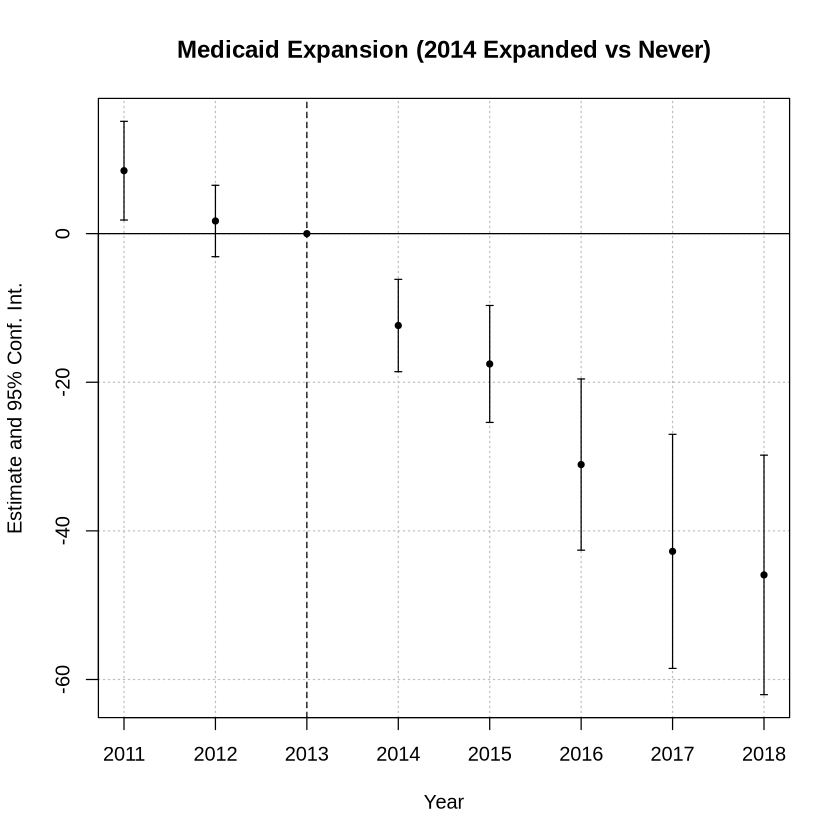

In [29]:
mod_es <- feols(uncomp_care / 1e6 ~ i(year, expanded, ref = 2013) | provider_number + year,
                cluster = ~ state,
                data = reg_dat)

iplot(mod_es, xlab = "Year", main = "Medicaid Expansion (2014 Expanded vs Never)")

## Problem 9

NOTE: 20,081 observations removed because of NA values (LHS: 20,081).



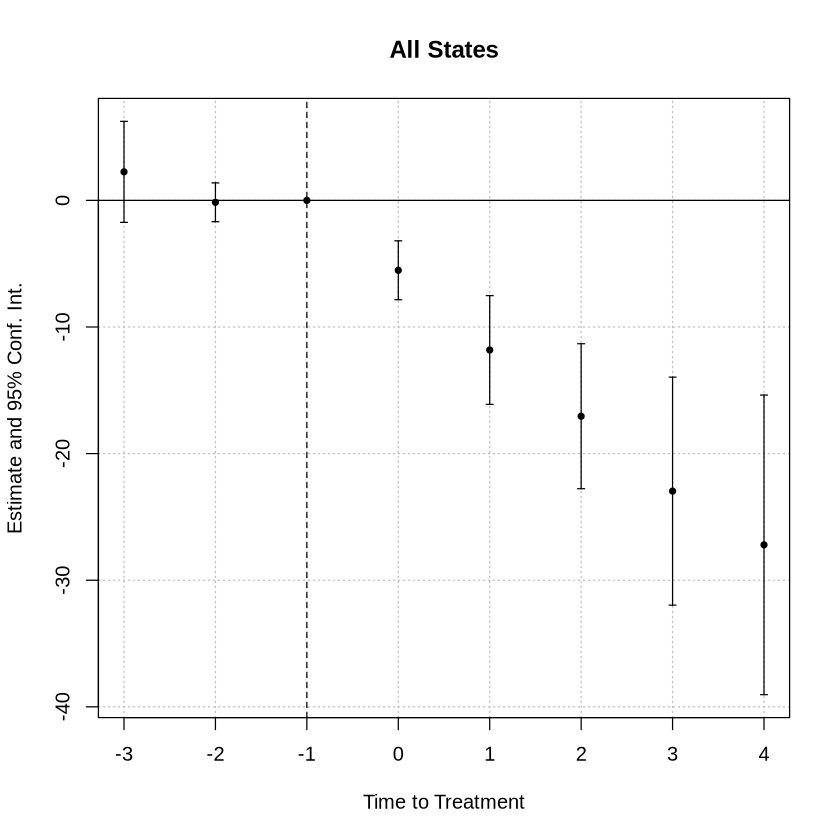

In [30]:
# Question 9: Event study with all states, event time variable, binned endpoints
reg_dat_full <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(
    expand_year   = year(as.Date(date_adopted)),
    time_to_treat = ifelse(expanded == FALSE, 0, year - expand_year),
    time_to_treat = ifelse(time_to_treat < -3, -3, time_to_treat),  # bin left at -3
    time_to_treat = ifelse(time_to_treat > 5, 5, time_to_treat)     # bin right at +5
  )

mod_es_full <- feols(tot_uncomp_care_charges / 1e6 ~ i(time_to_treat, expanded, ref = -1) | provider_number + year,
                     cluster = ~ state,
                     data = reg_dat_full)

iplot(mod_es_full, xlab = "Time to Treatment", main = "All States")

## Problem 10

Results show that Medicaid expansion reduces hospital uncompensated care, with effects growing larger over time. The post 2014 downward trend is seen in both event study graphs but the pre-trends in the graphs are not flat, which means we should be cautious interpreting the results as it may be due to an already downward trend. One limitation of the TWFE estimator is that it can be biased when states expand Medicaid at different times. 